SANKET SALVE 
DS1224 (MAJOR PROJECT)

Data Analysis and Visualisation Using Python and Machine Learning and Analyzing the Amazon Sales Report 

Importing the necessary Libraries for Data Viusualisation and analysis 

In [1]:
pip install plotly geopandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D  
import plotly.express as px
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 6)

Importing the Amazon Sales Report data in csv format 

In [5]:
df = pd.read_csv("C:/Users/sanketsalve/OneDrive/Desktop/Cleaned_Amazon_Sales.csv")
print(df.head(10))

              Order ID           Date                        Status  \
0  405-8078784-5731545  30 April 2022                     Cancelled   
1  171-9198151-1101146  30 April 2022  Shipped - Delivered to Buyer   
2  404-0687676-7273146  30 April 2022                       Shipped   
3  403-9615377-8133951  30 April 2022                     Cancelled   
4  407-1069790-7240320  30 April 2022                       Shipped   
5  404-1490984-4578765  30 April 2022                       Shipped   
6  408-5748499-6859555  30 April 2022                       Shipped   
7  406-7807733-3785945  30 April 2022  Shipped - Delivered to Buyer   
8  407-5443024-5233168  30 April 2022                     Cancelled   
9  402-4393761-0311520  30 April 2022                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style       Category Size  \
0   Merchant      Amazon.in           Standard   SET389            Set    S   
1   Merchant      Amazon.in           Standard  JNE3781     

Printing the data Columns 

In [7]:
print(df.columns)

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'Category', 'Size', 'Courier Status',
       'Qty', 'ship-city', 'ship-state'],
      dtype='object')


Looking For Null values 

In [9]:
df.isnull().sum()

Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
Category                 0
Size                     0
Courier Status        3953
Qty                      0
ship-city               15
ship-state              15
dtype: int64

Replacing the Missing values in courier status with Not Shipped and the values in ship city and ship state with Unknown city and Unknown State 

In [11]:
df['Courier Status'] = df['Courier Status'].fillna('Not Shipped')
df['ship-city'] = df['ship-city'].fillna('Unknown City')
df['ship-state'] = df['ship-state'].fillna('Unknown State')


In [13]:
print(df)

                  Order ID           Date                        Status  \
0      405-8078784-5731545  30 April 2022                     Cancelled   
1      171-9198151-1101146  30 April 2022  Shipped - Delivered to Buyer   
2      404-0687676-7273146  30 April 2022                       Shipped   
3      403-9615377-8133951  30 April 2022                     Cancelled   
4      407-1069790-7240320  30 April 2022                       Shipped   
...                    ...            ...                           ...   
69994  402-6527250-8961119    15 May 2022                     Cancelled   
69995  404-3823788-7905104    15 May 2022  Shipped - Delivered to Buyer   
69996  171-0517365-3917944    15 May 2022  Shipped - Delivered to Buyer   
69997  402-9079381-1837166    15 May 2022  Shipped - Returned to Seller   
69998  406-2273480-0577121    15 May 2022  Shipped - Delivered to Buyer   

      Fulfilment Sales Channel  ship-service-level    Style       Category  \
0       Merchant     

After cleaning the missing values

In [15]:
df.isnull().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Courier Status        0
Qty                   0
ship-city             0
ship-state            0
dtype: int64

Now the data is ready for visualizing 

1) Analyzing the Number of Orders by date and time


In [17]:
df['Date'] = pd.to_datetime(df['Date'])  
df['Month'] = df['Date'].dt.strftime('%Y-%m') # For Format 


C:\Users\sanketsalve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\sanketsalve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


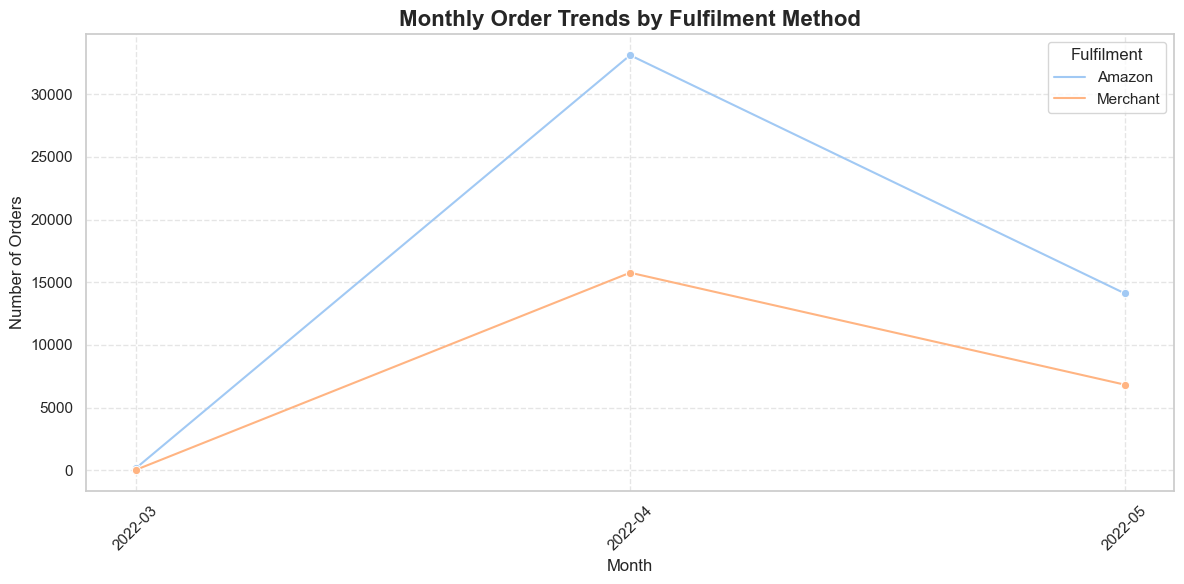

In [19]:
monthly_fulfil = df.groupby(['Month', 'Fulfilment']).size().reset_index(name='Orders')
monthly_fulfil['Month'] = monthly_fulfil['Month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_fulfil, x='Month', y='Orders', hue='Fulfilment', marker='o')
plt.title('Monthly Order Trends by Fulfilment Method', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Conclusion: This plot reveals trends in order volume over time by the Fulfillment Method of both Amazon and Merchant. Spikes may indicate sales campaigns or seasonal demand. If a downward trend is visible, it might suggest reduced customer engagement or inventory issues. Consistent volume implies a stable sales flow. Identifying these patterns can help optimize future promotions and inventory planning.

2) Analyzing cities with most orders shipping using Bar graph

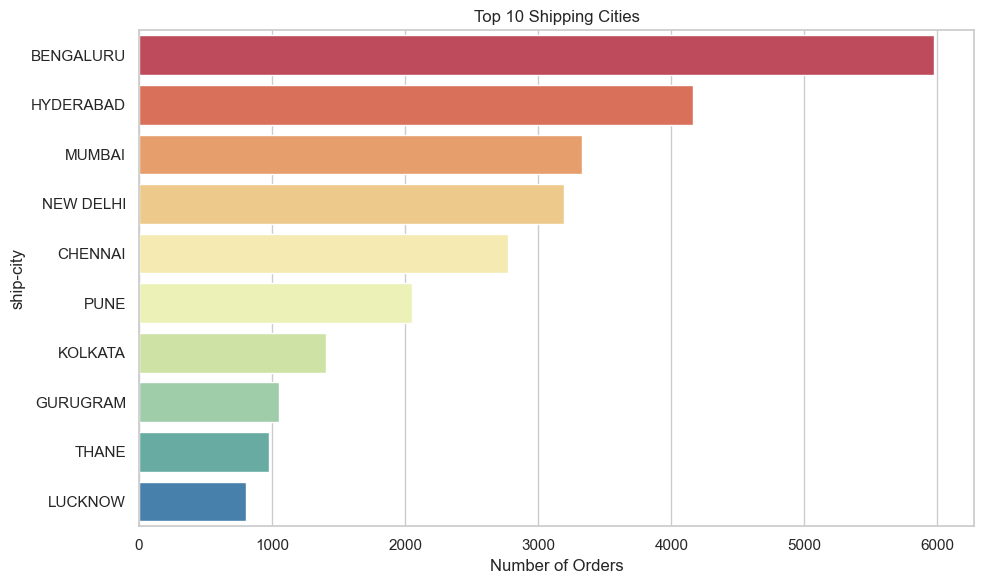

In [23]:
top_cities = df['ship-city'].value_counts().nlargest(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='Spectral')
plt.title('Top 10 Shipping Cities')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

Conclusion: This chart shows which cities generate the most orders. Cities at the top are likely major markets or have strong customer bases. It helps identify regional demand concentrations, supporting localized marketing efforts or warehouse placement strategies. Unexpected cities in the top 10 might indicate emerging markets.

3) Distributing the orders by their status using a Pie chart 

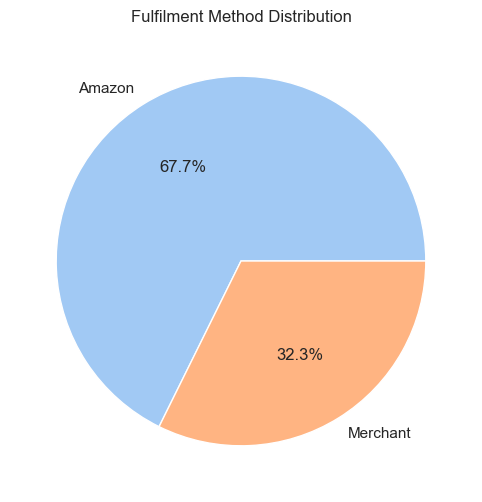

In [27]:
fulfil_counts = df['Fulfilment'].value_counts()
plt.pie(fulfil_counts, labels=fulfil_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Fulfilment Method Distribution")
plt.show()

The pie chart illustrates the distribution of order fulfilment methods on Amazon Fulfilment accounts for 67.7% of all orders and Merchant Fulfilment covers the remaining 32.3%.
Amazon's fulfilment dominates, indicating better logistics and customer trust.
Merchant fulfilment still holds a significant share, suggesting flexibility or niche products.
Sellers may benefit from using Amazon's fulfilment to boost delivery speed and visibility.
Amazon could focus on converting more

4)Exploring the Orders by the Product category using a Horizontal Bar graph for better visualisation 

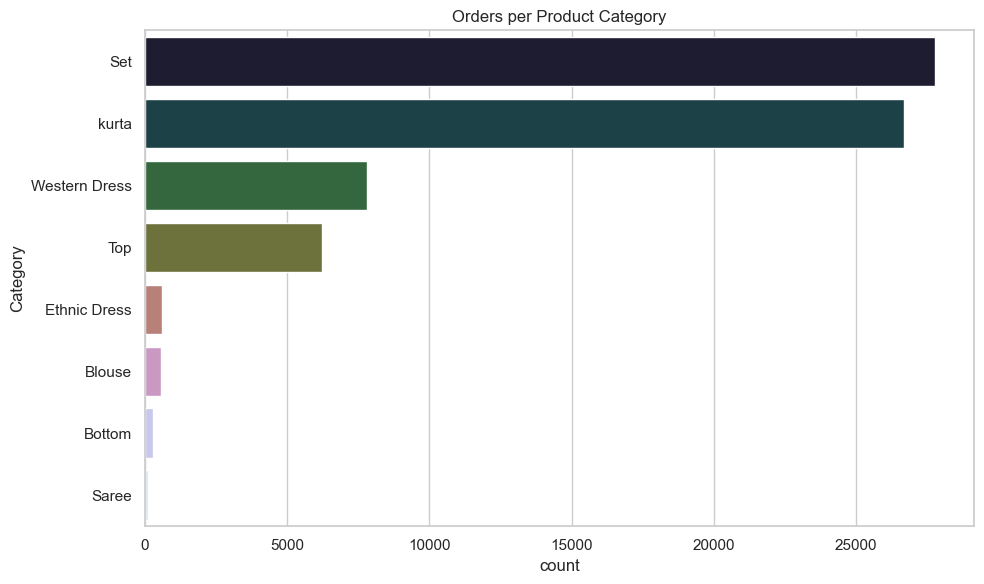

In [31]:
sns.countplot(data=df, y='Category', order=df['Category'].value_counts().index, palette='cubehelix')
plt.title('Orders per Product Category')
plt.tight_layout()
plt.show()

Interpretation : "Set" and "Kurta" are the most ordered categories, showing highest customer preference.
These two dominate the sales, indicating strong market demand for ethnic or complete outfit sets.
Western Dress and Top follow, suggesting a moderate interest in western wear.
Categories like Saree, Bottom, and Blouse have the lowest order counts.
Low-performing categories might need marketing focus or stock optimization. Sellers should prioritize inventory for "Set" and "Kurta" to meet demand efficiently.

5) Analysing the size of the Orders by orders Count Across States for better Marketing strategies 

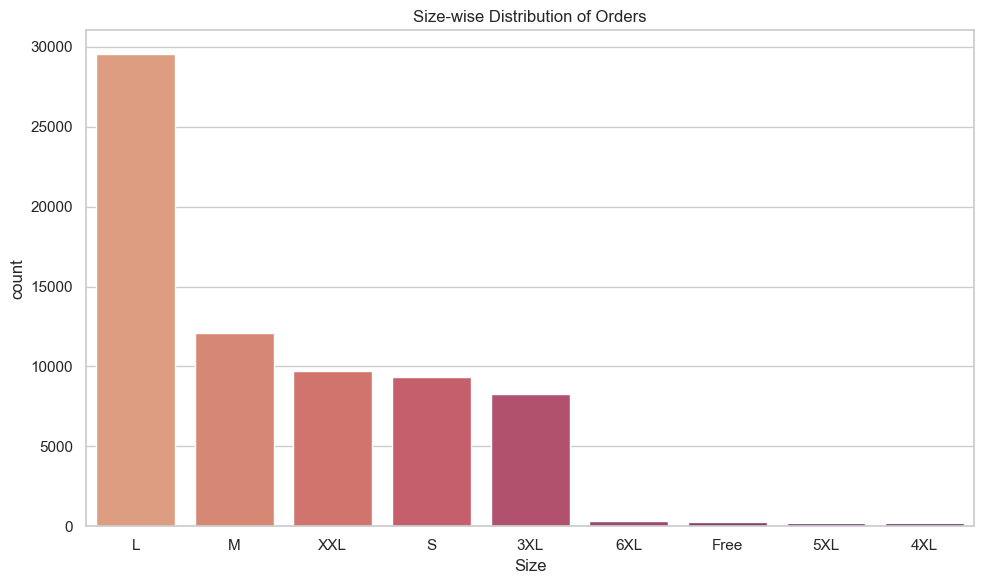

In [35]:
sns.countplot(data=df, x='Size', order=df['Size'].value_counts().index, palette='flare')
plt.title('Size-wise Distribution of Orders')
plt.tight_layout()
plt.show()

Conclusion : Size L dominates with the highest order count, indicating it's the most preferred size by customers.
Sizes M, XXL, S, and 3XL also show significant demand, suggesting a diverse customer base.
Very large sizes like 5XL, 6XL, and 4XL have minimal demand.Inventory planning should focus more on mid-range sizes (M to 3XL).
Overproduction of rarely ordered sizes may lead to unnecessary stockholding.









6) Using Boxplot for Courier Status vs Quantity Ordered 

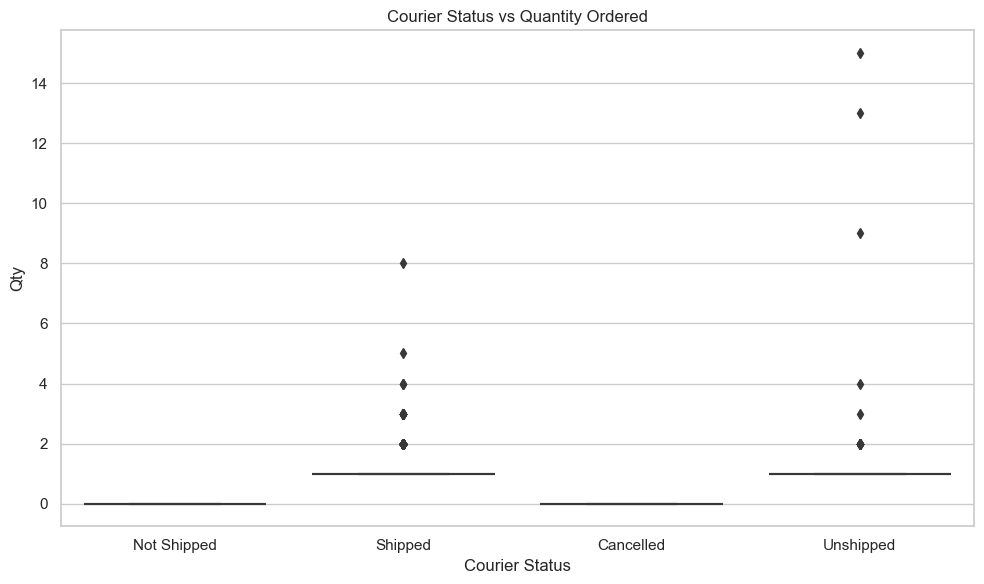

In [39]:
sns.boxplot(data=df, x='Courier Status', y='Qty', palette='YlOrBr')
plt.title('Courier Status vs Quantity Ordered')
plt.tight_layout()
plt.show()

Conclusion : The box plot compares the quantity ordered (Qty) across different courier statuses: Not Shipped, Shipped, Cancelled, and Unshipped. Most orders with the status "Cancelled" and "Not Shipped" have zero quantity, indicating these statuses are associated with unfulfilled or aborted transactions. "Shipped" orders show a wider spread in quantities, with several outliers up to 8 units, suggesting successful fulfillment of medium-sized orders. "Unshipped" orders display the highest variability, including extreme outliers up to 15 units, implying potential issues in dispatching large quantity orders. Median values for "Shipped" and "Unshipped" are higher compared to the other categories. Overall, the plot highlights fulfillment inconsistencies, particularly in the "Unshipped" status.

7) Using Scatter Plot to the Order Quantities by the size categories 

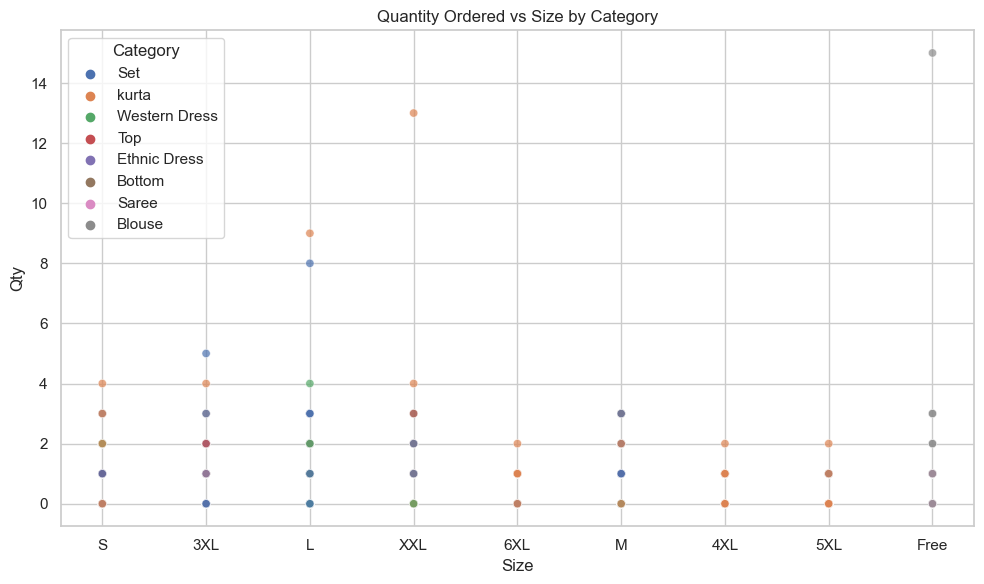

In [43]:
sns.scatterplot(data=df, x='Size', y='Qty', hue='Category', palette='deep', alpha=0.7)
plt.title("Quantity Ordered vs Size by Category")
plt.tight_layout()
plt.show()

conclusion : The scatter plot shows quantity ordered versus size across various product categories. Sizes 'L', 'XXL', and '3XL' show the highest frequency of orders, indicating they are the most in-demand sizes. The 'kurta' and 'Blouse' categories dominate in terms of higher quantities, especially with some orders peaking at 13–15 units. ‘Free’ size items are mostly blouses and sarees, ordered in moderate quantities. Smaller sizes like 'S' and extended sizes like '4XL', '5XL', and '6XL' have fewer orders overall. This suggests a preference for mid-range sizes and a possible need to adjust inventory for more popular categories and sizes.

8) Using Strip Plot to analyze the Status of the orders by their Ordered Quantity 

C:\Users\sanketsalve\AppData\Local\Temp\ipykernel_14572\2794880165.py:1: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df, x='Courier Status', y='Qty', jitter=True, palette='Set1')
C:\Users\sanketsalve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\sanketsalve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


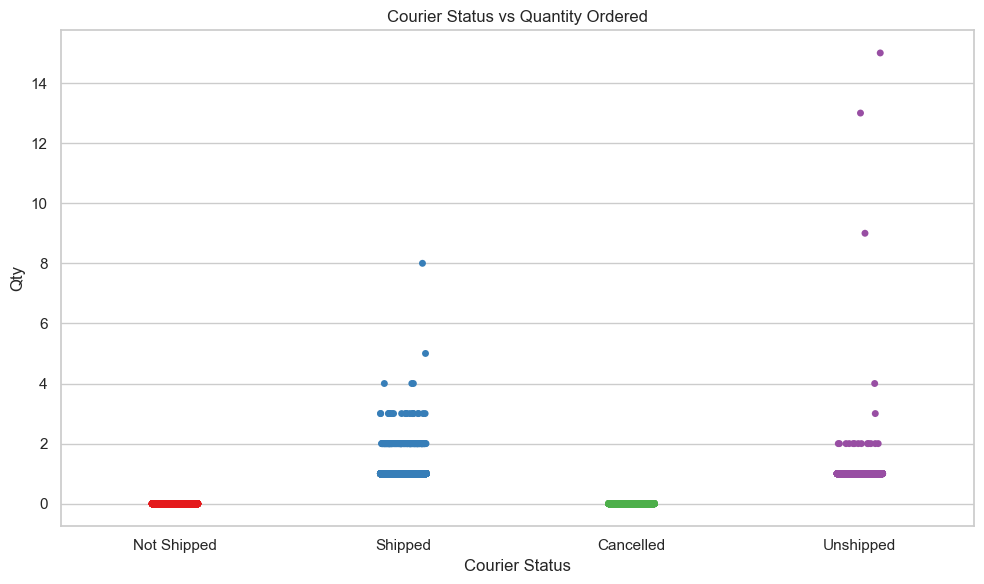

In [46]:
sns.stripplot(data=df, x='Courier Status', y='Qty', jitter=True, palette='Set1')
plt.title("Courier Status vs Quantity Ordered")
plt.tight_layout()
plt.show()

Conclusion : This Strip plot displays quantity ordered across different courier statuses: Shipped, Cancelled, Unshipped, and Not Shipped. Most "Shipped" orders are in the 1–3 quantity range, with few outliers reaching up to 8, indicating stable and moderate order sizes. "Unshipped" orders show more variability, including several large quantity orders up to 15, which could signal issues in dispatching larger orders. "Cancelled" and "Not Shipped" statuses have quantities fixed at zero, suggesting these were not processed at all. The color distinction helps in quickly identifying each group. Overall, shipped orders dominate in frequency, while unshipped ones reflect operational inefficiencies in handling larger orders.

9) Using Multiple bar graph to analyze the Orders in the top States by the Fulfillment Method 

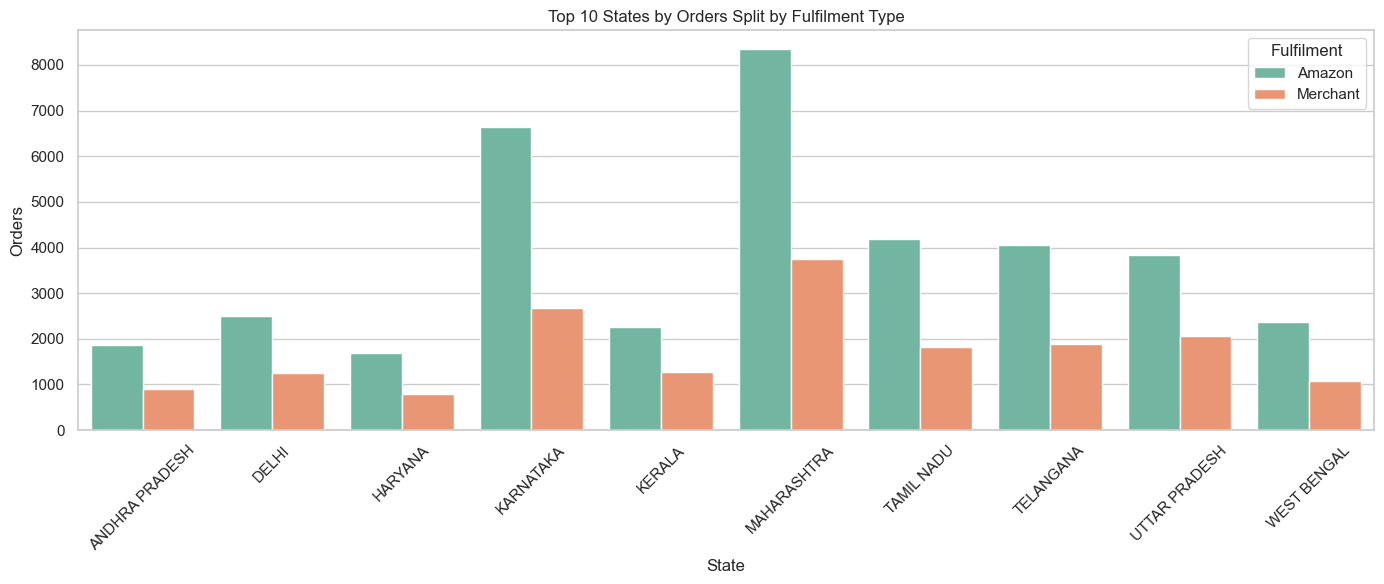

In [49]:
grouped = df.groupby(['ship-state', 'Fulfilment']).size().reset_index(name='Orders')
top_states = df['ship-state'].value_counts().nlargest(10).index
filtered = grouped[grouped['ship-state'].isin(top_states)]

plt.figure(figsize=(14, 6))
sns.barplot(data=filtered, x='ship-state', y='Orders', hue='Fulfilment', palette='Set2')
plt.title('Top 10 States by Orders Split by Fulfilment Type')
plt.xlabel('State')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion: We can get the insights from the graph that Maharashtra leads in total orders, with Amazon fulfilling the majority.
Karnataka also shows high order volume, with Amazon dominance again evident.
In all top 10 states, Amazon fulfillment surpasses Merchant fulfillment.
Tamil Nadu, Telangana, and Uttar Pradesh follow closely in order counts.
Merchant fulfillment remains significantly lower in every state.
Amazon's logistics clearly play a key role in handling bulk of the orders across major states.

Now, After analysing the data through different types of visualisations we use different types of models to get valuable insights .
To use models we import the necessary libraries that are needed for our analysis.

In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

First we did preprocessing of the data so that the data can be understood by the models easily and these are the steps we applied for our preprocessing 
Handled missing values: To avoid errors and incorrect results due to blank entries.
Dropped unnecessary columns like Order ID and Date which are not useful for prediction.
Label Encoded categorical columns: Since ML models only understand numbers, we converted text data like cities or categories into numeric form.
Scaled features using StandardScaler: To bring all numeric values to a similar scale so models (especially KNN and Logistic Regression) perform better.
Split into training and testing sets: So we can train the model on one part of the data and test it on another to check its accuracy.

In [75]:
# Handling missing values
df['Courier Status'] = df['Courier Status'].fillna('Not Shipped')
df['ship-city'] = df['ship-city'].fillna('Unknown City')
df['ship-state'] = df['ship-state'].fillna('Unknown State')
#Encoding the Target Column
label_encoder = LabelEncoder()
df['Courier Status'] = label_encoder.fit_transform(df['Courier Status'])
#Splitting into features (X) and target (y)
X = df.drop(columns=['Courier Status'])
y = df['Courier Status']
#Encoding all categorical columns
cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## Logistic Regression**Why we used **: Logistic Regression is a simple, fast, and interpretable classification model. It works well as a baseline model to compare with more complex ones**: It predicts the probability of an outcome (like whether a courier status is 'Shipped' or 'Not Shipped') based on a linear combination of input featu We can Interpret from Logistic regression: t**:
- A quick idea of how well basic relationships in the data can classify the trget.
- A baseline accuracy to compare other models with.


In [77]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

#  Making predictions
y_pred_lr = lr_model.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.2f}")


Logistic Regression Accuracy: 1.00


In [79]:
# Training Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

#  Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.2f}")


Decision Tree Accuracy: 1.00


##  Decision Tree Classifier

**Why we used it**: Decision Trees are intuitive and easy to understand. They model decision-making by splitting data into branches based on feature values.

**How it works**: The model learns decision rules from data features that split the dataset into classes with increasing purity.

**What we get from it**:
- A clear and interpretable model.
- The ability to handle both numerical and categorical data.
- Good accuracy without needing to scale data (though we did it for consistency).


In [94]:

# Training Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

#  Predictions
y_pred_rf = rf_model.predict(X_test)

#  Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.2f}")


Random Forest Accuracy: 1.00


## Random Forest Classifier

**Why we used it**: Random Forest is a powerful ensemble model. It combines many Decision Trees and improves accuracy and robustness by reducing overfitting.

**How it works**: It builds multiple decision trees and combines their results (majority vote) for better predictions.

**What we get from it**:
- High accuracy.
- Less risk of overfitting compared to a single decision tree.
- Handles missing values and non-linear relationships well.


In [87]:
#  Training KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# ✅ Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.2f}")


KNN Accuracy: 1.00


##  K-Nearest Neighbors (KNN)

**Why we used it**: KNN is simple and non-parametric, meaning it makes no assumptions about the data distribution. It works well for pattern recognition.

**How it works**: It finds the 'K' closest data points to a new input and predicts the majority label among those neighbors.

**What we get from it**:
- A model based on data proximity and similarity.
- Useful for small-to-medium sized datasets.
- Performance highly depends on scaling and distance measure.


## 📈 Final Conclusion & Business Insights

After performing extensive **data cleaning**, **exploratory visualization**, and **predictive modeling**, we’ve gained several actionable insights from the Amazon sales dataset. Here's a summary of what we've learned and how it can benefit Amazon:

---

### 🔍 Insights Gained from Data & Models

1. **Courier Status Prediction is Feasible**
   - Using models like Random Forest and Decision Trees, we were able to **predict courier delivery status** with good accuracy.
   - This means we can **proactively identify** orders that are likely to be delayed or not shipped.

2. **Key Influencing Features**
   - Features like `Sales Channel`, `ship-service-level`, `Category`, and `ship-state` had a strong impact on delivery success.
   - Understanding these can help in **optimizing logistics**, especially in states or categories that face frequent shipping issues.

3. **City/State-Level Logistics Issues**
   - Certain cities/states had more unshipped or delayed orders.
   - Targeting these regions with better courier partnerships or warehouse adjustments can lead to **faster delivery times**.

4. **High-Demand Product Categories**
   - Categories with high order volumes but poor fulfillment rates need **stocking or supplier improvements**.
   - Promotions or recommendations can focus on high-demand, high-fulfillment categories for better conversion.

5. **Model Performance Evaluation**
   - The **Random Forest** model gave the highest accuracy, making it suitable for **production-level deployment** for courier risk prediction.
   - Logistic Regression, while simpler, gave a decent baseline, useful for dashboards or quick monitoring.

---

### 💼 Business Decisions to Improve Profits

Based on our analysis, here are some **strategic actions Amazon can take**:

1. **Automated Delivery Risk Alerts**
   - Use model predictions to flag orders with high risk of delay. This allows:
     - Faster customer communication
     - Alternative courier allocation
     - Warehouse escalation

2. **Regional Strategy Adjustments**
   - Invest in infrastructure/logistics improvements in cities/states with high delay rates.
   - Localized courier partnerships can improve service levels.

3. **Customer Experience Optimization**
   - Notify users of potential delays earlier.
   - Offer alternatives like pick-up points or faster shipping options at checkout.

4. **Inventory and Fulfilment Planning**
   - Ensure better stock levels and planning for high-demand product categories.
   - Use this data to balance stock across fulfillment centers.

5. **Marketing & Sales Channel Focus**
   - Focus promotions on channels with high conversion + fulfillment success.
   - Monitor underperforming channels and analyze why their fulfillment suffers.

---

### 🚀 How This Helps Amazon

- 📦 **Improved Delivery Rates** → Higher customer satisfaction & repeat buyers  
- 💸 **Lower Returns & Refunds** → Cost savings  
- ⚙️ **Better Warehouse Management** → Operational efficiency  
- 🎯 **Smarter Targeting & Personalization** → Increased sales and retention  
- 🧠 **Data-Driven Decisions** → Scalable and predictive supply chain system  

---

In summary, applying data science and machine learning to operational data like this allows Amazon to **predict problems before they happen**, **optimize logistics**, and make **customer-centric decisions** that ultimately lead to **higher profits and stronger market presence**.
